In [2]:
import numpy as np
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import os.path as op
from  nilearn.datasets import fetch_surf_fsaverage
from os import listdir

fsaverage = fetch_surf_fsaverage()

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'


### transform output.npy files from fit_grad_only_aligned.py into format compatible with plotting 


In [ ]:
# transform output.npy files from fit_grad_only_aligned.py into format compatible with plotting 

from utils import get_basic_mask, saveGradToNPFile
from brainspace.utils.parcellation import map_to_labels

mask, labeling_noParcel = get_basic_mask()

subs_npfiles = [f[4:6] for f in listdir(op.join(bids_folder,grad_folder)) if f[6:9] == '_se']

for sub in subs_npfiles:

    gm = np.load(op.join(bids_folder,grad_folder,f'sub-{sub}_ses-1_ref-p-align_fsav5_unfiltered.npy'))
    grad = [None] * np.shape(gm)[1]
    for i, g in enumerate(gm.T):
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

    saveGradToNPFile(grad, sub,ses=1, specification='_ref-aligned_',bids_folder=bids_folder)


understand what/how much is changed with 
* ref aligned

## plot average gradient

Text(0.5, 0.98, 'average')

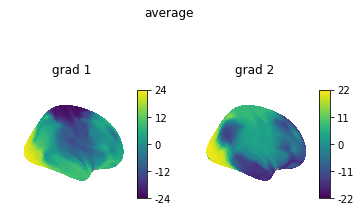

In [3]:
file = op.join(bids_folder,grad_folder, 'sub-average_cmunfil_01/ses-1/sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-R_grad1_noParcel.surf.gii')
grad1_right_av =  nib.load(file).agg_data()

file = op.join(bids_folder,grad_folder, 'sub-average_cmunfil_01/ses-1/sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-R_grad2_noParcel.surf.gii')
grad2_right_av =  nib.load(file).agg_data()

figure, axes = plt.subplots(nrows=1, ncols=2, subplot_kw=dict(projection='3d'))
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad1_right_av,cmap='viridis',view='medial',axes=axes[0])
axes[0].set(title='grad 1')
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad2_right_av,cmap='viridis',view='medial',axes=axes[1])
axes[1].set(title='grad 2')
figure.suptitle(f'average')

In [16]:
# align average with Margulies's gradients
sub='average_cmunfil_01'

av_gm = np.load(op.join(bids_folder,grad_folder,f'gm_av1-4_unfiltered.npy'))
print(av_gm.shape)

from utils import get_basic_mask, saveGradToNPFile
from brainspace.utils.parcellation import map_to_labels

mask, labeling_noParcel = get_basic_mask()

grad = [None] * np.shape(av_gm)[1]
for i, g in enumerate(av_gm.T):
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

print(grad1_right_av.shape) #comparison
print(np.shape(grad))

grad1 = np.split(grad[0],2) # for i, hemi in enumerate(['L', 'R']): --> left first
grad2 = np.split(grad[1],2) # for i, hemi in enumerate(['L', 'R']): --> left first

print(np.shape(grad1))

grad1_r = grad1[1]
grad2_r = grad2[1]

print(grad1_r.shape)
# /Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/gm_av1-4_unfiltered.npy

(18715, 2)
(10242,)
(2, 20484)
(2, 10242)
(10242,)


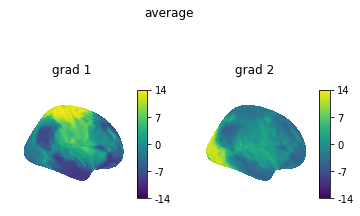

In [19]:
figure, axes = plt.subplots(nrows=1, ncols=2, subplot_kw=dict(projection='3d'))
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad1_r,cmap='viridis',view='medial',axes=axes[0])
axes[0].set(title='grad 1')
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad2_r,cmap='viridis',view='medial',axes=axes[1])
axes[1].set(title='grad 2')
figure.suptitle(f'average')


Text(0.5, 0.98, 'sub-01')

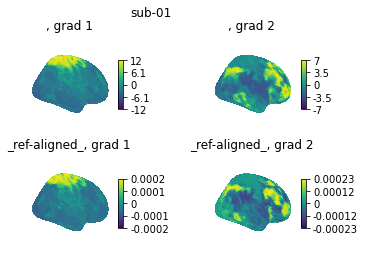

In [40]:
# plotting from npy files
sub = '01'

figure, axes = plt.subplots(nrows=2, ncols=2, subplot_kw=dict(projection='3d'))

for n1, ref_al in enumerate(['', '_ref-aligned_']): 
    for n2, grad_n in enumerate([1,2]):
        grad = np.load(op.join(bids_folder,grad_folder,f'sub-{sub}/ses-1/grad{grad_n}_noParcel{ref_al}.npy'))
        grad_r = np.split(grad,2)[1] #--> left first
        nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad_r,cmap='viridis',view='medial',axes=axes[n1,n2])
        axes[n1,n2].set(title=f'{ref_al}, grad {grad_n}')

figure.suptitle(f'sub-{sub}')

Text(0.5, 0.98, 'sub-01, _ref-aligned_')

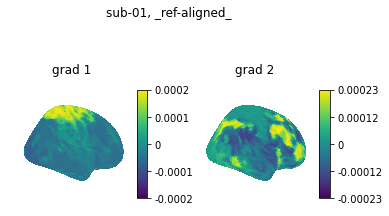

In [66]:
sub = '01'
ref_al = '_ref-aligned_' # '' #
file = op.join(bids_folder,grad_folder,f'sub-{sub}/ses-1/sub-{sub}_ses-1_task-risk_space-fsaverage5_hemi-R_grad1_noParcel{ref_al}.surf.gii')
grad1_right_sub1 =  nib.load(file).agg_data()

file = op.join(bids_folder,grad_folder,f'sub-{sub}/ses-1/sub-{sub}_ses-1_task-risk_space-fsaverage5_hemi-R_grad2_noParcel{ref_al}.surf.gii')
grad2_right_sub1 =  nib.load(file).agg_data()

figure, axes = plt.subplots(nrows=1, ncols=2, subplot_kw=dict(projection='3d'))
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad1_right_sub1,cmap='viridis',view='medial',axes=axes[0])
axes[0].set(title='grad 1')
nplt.plot_surf_stat_map(surf_mesh=fsaverage.infl_right, stat_map=grad2_right_sub1,cmap='viridis',view='medial',axes=axes[1])
axes[1].set(title='grad 2')

figure.suptitle(f'sub-{sub}, {ref_al}')

--> for sub-01, ref-aligned and (unaligned)-filtered look quite similar, most notably the scale is very different

In [10]:
np.shape(grad[:,0])

(18715,)

In [ ]:
saveGradToNPFile(grad, sub,1, specification='',bids_folder='/Users/mrenke/data/ds-stressrisk')